# Real Estate Data Analysis

In this project, I will analyze the relationship between socioeconomic, demographic, and geographic characteristics and house values in California.

It involves combining **exploratory data analysis** and **machine learning** to investigate the factors associated with **real estate prices** and evaluate whether these characteristics can be used to **predict house values**.

------

I will use the following the pipeline below:

1. **Understand the dataset and its variables.**
2. **Explore the data and identify relevant patterns and relationships.**
3. **Prepare the data for machine learning.**
4. **Split the data into training and testing sets.**
5. **Establish a baseline for model evaluation.**
6. **Train and compare machine learning models.**
7. **Evaluate the best-performing model and interpret its results.**
8. **Discuss the findings and limitations.**

------

In **this notebook**, I will focus on **the machine learning stages of the project**, **covering steps 3 to 8** of the pipeline. Based on the **insights** that I've obtained during the **exploratory data analysis**, **the dataset will be prepared** for machine learning and **divided into training and testing sets**.

A **baseline** will first be established **to provide a reference for model evaluation**. Then, different machine learning models **will be trained and compared** using **Mean Absolute Error (MAE)**.

Finally, the **best-performing model** will be **further evaluated and interpreted** through **prediction analysis** and **feature importance**.

## Importing the libraries

In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

# Data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
from src.evaluation import (
    calculate_mae,
    calculate_error_reduction
)
from src.visualization import (
    plot_model_comparison,
    plot_actual_vs_predicted,
    plot_feature_importance,
    plot_residuals,
    plot_residual_distribution
)

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Data loading
from src.data import load_california_housing

## Data Loading

The California Housing dataset is loaded using a reusable data loading function from the project's `src/` module. The function retrieves the dataset provided by Scikit-learn and returns it as a pandas DataFrame.

The dataset contains information about housing districts in California and will be used throughout the modelling stage of this project.

In [4]:
df = load_california_housing()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


------

## Preparing Data for Machine Learning

Based on the exploratory data analysis, the next step is to **investigate whether the available characteristics can be used to estimate house values**.

Before training machine learning models, the **dataset must be prepared** by separating the **input features** (`x`) from the **target variable** (`y`).

### Data Separation

In [5]:
x = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

The remaining variables will be used as input features for the models.

In [6]:
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


The dataset has now been divided into:

- **Target (`y`)**: `MedHouseVal`, which represents **the value to be predicted**.
- **Features (`x`)**: **all remaining variables**, which will be used as input for the machine learning models.

------

### Train-Test Split

The data must be **divided into training and testing sets** to evaluate how well the models perform.

You might think: "I have **20,640 observations** in the dataset. **Why not use all of them to train the model?**"

The problem is that we need to determine whether the model can generalize the patterns it learns rather than simply perform well on observations it has already seen.

------

This split allows us to answer two different questions:

**Training:** Can the model learn relationships between the available features and house values?

**Testing:** After learning these relationships, can the model use them to predict house values for observations it has never seen before?

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42)

print(f"Training data: {x_train.shape}")
print(f"Test data: {x_test.shape}")

Training data: (16512, 8)
Test data: (4128, 8)


The dataset was divided into **80% training data** and **20% testing data**.

The training data will be used to teach the models the relationships between the available features and house values. The testing data will remain separate during training and will only be used to evaluate how well the models perform on unseen observations.

The `random_state` parameter was fixed to make the experiment reproducible.

------

## Modelling

### Baseline

Before training machine learning models, **a baseline is established as a reference** for evaluating model performance.

A baseline is a simple solution that provides a performance benchmark. The machine learning models should outperform this initial reference to demonstrate that they are learning useful patterns from the data.

In this project, the baseline will predict the average house value from the training set for every observation in the test set.

In [8]:
baseline_prediction = y_train.mean()
# This value represents the average of the property values ​​present only in the training set.
print(f"Previsão da baseline: {baseline_prediction:.2f}")

Previsão da baseline: 2.07


The baseline prediction represents the average house value observed in the training data.

However, predicting a single average value for every observation is a very simple approach. To evaluate how inaccurate these predictions are, I will calculate the Mean Absolute Error (MAE).

To do this, I will import the following metric from scikit-learn to generate a prediction for each test record: MAE (mean_absolute_error).

In [9]:
baseline_predictions = [baseline_prediction] * len(y_test)

baseline_mae = calculate_mae(
    y_test,
    baseline_predictions)
print(f"Baseline MAE: {baseline_mae:.2f}") 

Baseline MAE: 0.91


The baseline achieved an MAE of approximately **0.91**, corresponding to an average prediction error of approximately **US$91,000**.

This result provides a reference that will be used to determine whether the machine learning models can make more accurate predictions.

------

### First model: **Linear Regression**

**Linear Regression** will be used as the first machine learning model to **determine whether the relationships between the available features and house values can improve predictions compared to the baseline**.

The model attempts to **identify relationships** between the **input features** (`x`) and the **target variable** (`y`) and use these relationships to estimate house values.

In [10]:
model = LinearRegression()
model.fit(x_train, y_train) # Training
y_pred = model.predict(x_test)
# The model receives x_test and generates y_pred, characteristics of features it never saw during training.

In [11]:
print("Real values:")
print(y_test.head())

print("\nPredictions:")
print(y_pred[:5])

Real values:
20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
Name: MedHouseVal, dtype: float64

Predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


By comparing the predictions with the actual values, we can already see that some estimates are **close to the real values** while others show more **considerable errors**.

------

**To evaluate the model**, I will use **MAE** to calculate the **average absolute difference** between the **actual values** and the **predictions** across all 4,128 observations in the test set.

In [12]:
lr_mae = calculate_mae(y_test, y_pred)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Linear Regression MAE: {lr_mae:.2f}")

Baseline MAE: 0.91
Linear Regression MAE: 0.53


In [13]:
improvement = calculate_error_reduction(
    baseline_mae, lr_mae)

print(f"Error reduction: {improvement:.2f}%")

Error reduction: 41.15%


The Linear Regression model achieved an MAE of approximately **0.53**, corresponding to an average prediction error of approximately **US$53,000**.

Compared with the baseline MAE of approximately **0.91**, the result shows that **the model learned useful relationships** from the **available features** and **significantly improved the predictions**.

------

### Second model: **Random Forest Regressor**

The **Random Forest Regressor** will be used as a second model to **investigate whether a more flexible algorithm can capture relationships that Linear Regression may not represent effectively**.

**Unlike Linear Regression**, Random Forest can model **more complex relationships** between the **available features** and the **target variable**.

In [14]:
random_forest = RandomForestRegressor(
    n_estimators=100, # specifies the number of decision trees to be built 
    random_state=42
)

In [15]:
random_forest.fit(x_train, y_train)

rf_predictions = random_forest.predict(x_test)

rf_mae = calculate_mae(
    y_test,
    rf_predictions
)

------

## Model Evaluation

After training the models, their performance can be compared using **Mean Absolute Error (MAE)**. **Lower MAE values indicate** that the predictions are, on average, **closer to the actual house values**.

------

### Model Comparison

The following table compares the performance of the baseline and the machine learning models.

In [16]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae
    ]
})

results["Error (USD)"] = (
    results["MAE"] * 100000).round(2)

results

,Model,MAE,Error (USD)
0,Baseline,0.906069,90606.85
1,Linear Regression,0.533200,53320.01
2,Random Forest,0.327843,32784.34


The following chart provides a **visual comparison of the prediction error** achieved by each approach.

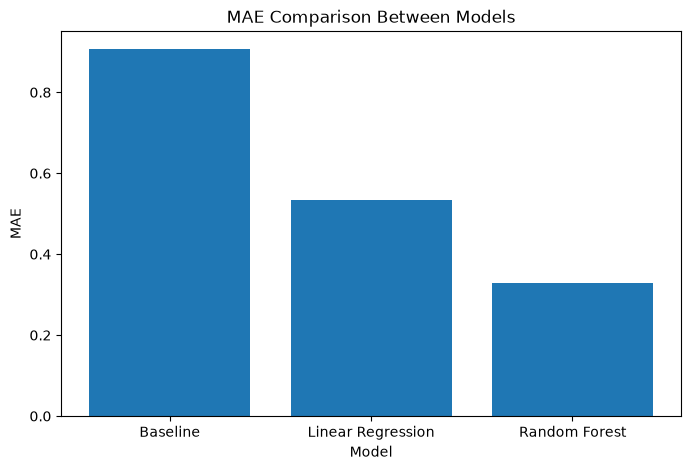

In [17]:
plot_model_comparison(results)

The results show a **clear improvement** from the baseline to **the machine learning models**.

The **Random Forest achieved the lowest MAE** among the evaluated approaches, **making it the best-performing model** in this project.

------

### Actual vs. Predicted Values

Since the Random Forest **achieved the lowest MAE**, its predictions will be examined in more detail.

The following visualization compares **the actual house values with the values predicted** by the Random Forest model.

The diagonal reference line represents a **perfect prediction**, where the predicted value is equal to the actual value.

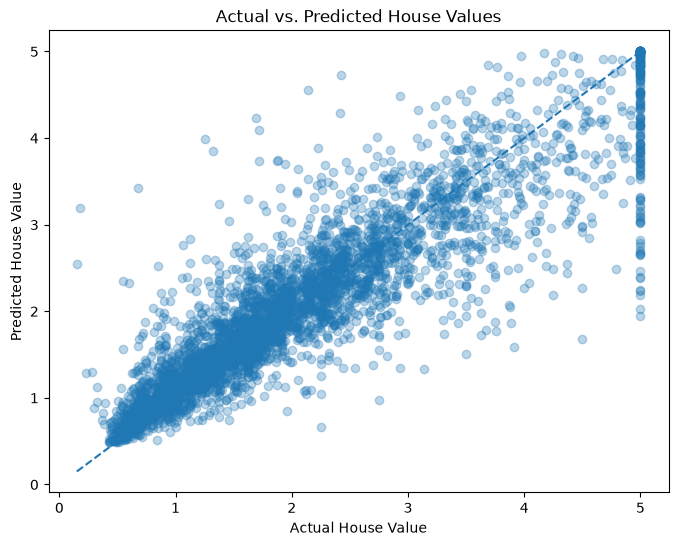

In [18]:
plot_actual_vs_predicted(y_test, rf_predictions)

**The points** generally **follow the diagonal trend**, indicating that **the model captures the overall relationship between the available features and house values**.

However, **some dispersion remains around the reference line**, showing that **prediction errors are still present**. The model also appears to have more **difficulty predicting some observations at higher house values**.

------

### Residual Analysis

Predictions can also be evaluated by examining the **residuals**, which represent the difference between the actual and predicted values.

For this analysis, residuals are calculated as:

**Residual = Actual Value − Predicted Value**

Positive residuals indicate that the model **underestimated** the house value, while negative residuals indicate that the model **overestimated** it. The following plots help examine whether prediction errors are distributed randomly and how frequently different error magnitudes occur.

#### Residuals vs. Predicted Values

A residual plot can reveal patterns in the prediction errors. Ideally, the residuals should be distributed around zero without a clear systematic pattern.

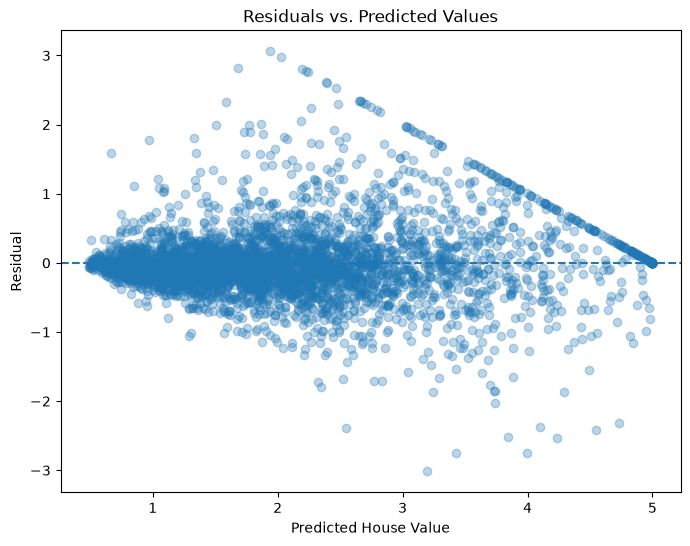

In [19]:
residuals = y_test - rf_predictions

plot_residuals(
    rf_predictions,
    residuals
)

This visualization makes it easier to identify whether the model tends to systematically overestimate or underestimate house values across different prediction ranges.

A random distribution around zero would suggest that the remaining errors do not follow an obvious pattern, while visible structures may indicate relationships that the model does not capture well.

#### Distribution of Residuals

The following histogram shows how the prediction errors are distributed.

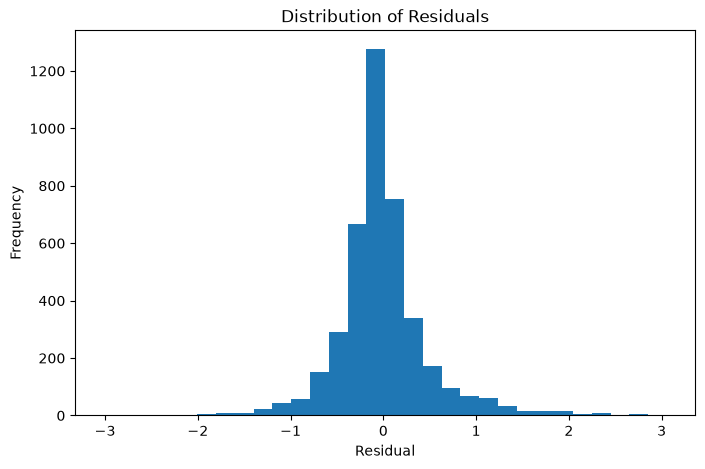

In [20]:
plot_residual_distribution(residuals)

A concentration of residuals around zero indicates that many predictions are relatively close to the actual values.

However, observations farther from zero represent larger prediction errors and help reveal cases where the model had more difficulty estimating house values.

------

### Random Forest Feature Importance

The **feature importance analysis** helps identify which variables contributed the most to **the predictions made by the Random Forest model**.

In [21]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False)

feature_importance

,Feature,Importance
0,MedInc,0.524955
5,AveOccup,0.138383
6,Latitude,0.088879
7,Longitude,0.088627
1,HouseAge,0.054664
2,AveRooms,0.044202
4,Population,0.030626
3,AveBedrms,0.029665


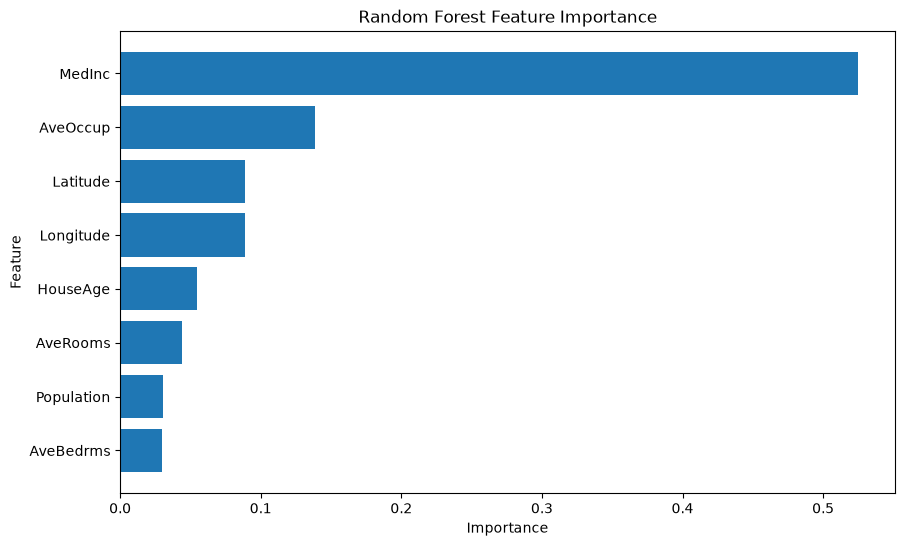

In [22]:
# Feature Importante Graphic
plot_feature_importance(feature_importance)

`MedInc` was the most important feature, accounting for approximately **52.5% of the total importance assigned by the model**.

This result is consistent with the exploratory data analysis, where `MedInc` also showed the strongest relationship with `MedHouseVal`.

`AveOccup`, `Latitude`, and `Longitude` also contributed relevant information to the model.

Although `Latitude` and `Longitude` did not show the strongest individual linear correlations with house values, the Random Forest assigned relevant importance to both variables. This reinforces an observation from the geographic analysis: location contains useful information for estimating house values.

------

### Model Improvement

The **performance improvement** of the **Random Forest** can be measured by comparing its MAE with the baseline and the Linear Regression model.

In [23]:
rf_improvement_baseline = calculate_error_reduction(
    baseline_mae, rf_mae)

rf_improvement_lr = calculate_error_reduction(
    lr_mae, rf_mae)

print(
    f"Reduction in error compared to baseline: "
    f"{rf_improvement_baseline:.2f}%")

print(
    f"Reduction in error compared to Linear Regression: "
    f"{rf_improvement_lr:.2f}%")

Reduction in error compared to baseline: 63.82%
Reduction in error compared to Linear Regression: 38.51%


The Random Forest reduced the prediction error by approximately **63.82% compared to the baseline** and **38.51% compared to Linear Regression**.

The progression of the evaluated approaches can be summarized as:

**Baseline**  
MAE = 0.906

↓ Improvement

**Linear Regression**  
MAE = 0.533

↓ Further improvement

**Random Forest**  
MAE = 0.328

------

## Results and Discussion

The machine learning models showed a clear improvement over the baseline approach.

The baseline achieved an MAE of approximately **0.91**, corresponding to an average prediction error of approximately **US$90,607**.

Linear Regression reduced the MAE to approximately **0.53**, while the Random Forest achieved the best performance with an MAE of approximately **0.33**, corresponding to an average prediction error of approximately **US$32,784**.

Compared with the baseline, the Random Forest reduced the average prediction error by approximately **63.82%**.

The feature importance analysis also reinforced findings from the exploratory data analysis. `MedInc` was the most important feature for the Random Forest model, while geographic variables also contributed relevant information to the predictions.

Overall, the results demonstrate that the available socioeconomic, demographic, and geographic characteristics contain useful information for predicting house values.

------

## Limitations

This project has **some limitations** that should be considered when interpreting the results.

- The analysis is based on a **historical dataset** and may not represent **current housing market** conditions.
- The target variable **has an apparent upper limit** around US$500,000, which may affect the distribution of the data and the model's predictions.
- The dataset contains **aggregated information** about housing areas rather than detailed information about individual properties.
- The models were evaluated using a single train/test split and limited hyperparameter tuning.

------

## Conclusion

This project explored the **relationship** between socioeconomic, demographic, and geographic characteristics and **house values** in California.

The exploratory analysis **identified median income** as the **variable most strongly associated with house values**, while geographic patterns suggested that **location also played an important role**.

The machine learning experiments demonstrated that **using these features provided a substantial improvement over a simple baseline approach**. Among the evaluated models, the Random Forest Regressor achieved** the best performance** at this point, reducing the Mean Absolute Error by approximately **63.82%** compared to the baseline.

My feature importance analysis reinforced the exploratory findings, with **median income** being the most **important feature** for the model.

Geographic variables also showed relevant importance, highlighting the contribution of **location** to housing **value predictions**.

Overall, this project demonstrated how **exploratory data analysis and machine learning** can be combined to investigate patterns in real-world data and build useful predictive models.